# 🪸 Deteksi Pemutihan Karang (Coral Bleaching) dengan U-Net — Versi Perbaikan

Notebook ini melakukan **segmentasi citra** terumbu karang dengan **U-Net** untuk memisahkan tiap piksel ke 4 kelas — **Background, Karang Sehat, Karang Memutih (Bleached), Karang Mati** — lalu menghitung **rasio pemutihan** per gambar.

**Perbaikan utama dibanding versi awal:**
1. **Pemetaan kelas diperbaiki** agar sesuai taksonomi resmi Coralscapes (39 kelas, ID 1–39; nilai **0 = void/tak-berlabel**).
2. **Normalisasi ImageNet** ditambahkan (wajib untuk encoder pra-latih).
3. **Augmentasi data** (albumentations) untuk mengurangi *overfitting*.
4. **`ignore_index`** agar piksel void tidak mengotori loss & metrik.
5. **Bobot kelas dihitung otomatis** dari distribusi piksel asli.
6. **Rasio aspek dijaga** (validasi 512×1024) + *random crop* saat training.
7. Metrik utama: **mIoU per kelas** + **Coral mIoU** (rata-rata kelas karang saja).

> Dataset: `EPFL-ECEO/coralscapes` (Sauder et al., 2025) — 2075 citra, 39 kelas bentik, Laut Merah.

## Langkah 1 — Cek GPU
Memastikan runtime Colab memakai GPU (menu *Runtime → Change runtime type → T4 GPU*).

In [3]:
!nvidia-smi

Thu Jul  2 13:22:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Langkah 2 — Pasang library & impor
`segmentation-models-pytorch` menyediakan arsitektur U-Net siap pakai; `albumentations` menerapkan augmentasi pada citra **dan** masker secara sinkron.

In [4]:
!pip -q install datasets segmentation-models-pytorch albumentations

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__, "| CUDA tersedia:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128 | CUDA tersedia: True


## Langkah 3 — Konfigurasi, seed, & muat dataset
Semua *hyperparameter* dikumpulkan di satu tempat agar mudah diubah. `SEED` membuat hasil lebih dapat direproduksi.

In [5]:
from datasets import load_dataset

# ---- Konfigurasi ----
SEED = 42
NUM_CLASSES = 4            # 0=Background, 1=Healthy, 2=Bleached, 3=Dead
IGNORE_INDEX = 255         # label untuk piksel void (diabaikan loss & metrik)
BATCH_SIZE = 2             # kecil agar hemat VRAM T4
CROP_SIZE = 512            # ukuran random crop saat training
VAL_SIZE = (512, 1024)     # (tinggi, lebar) validasi -> menjaga rasio 2:1
EPOCHS = 15                # turunkan (mis. 8-10) bila waktu Colab terbatas
LR = 1e-4
WEIGHT_DECAY = 1e-4
CKPT_PATH = "/content/best_unet_coral.pth"

# ---- Reproduktibilitas ----
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- Muat dataset ----
dataset = load_dataset("EPFL-ECEO/coralscapes")
print(dataset)

Device: cuda


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00002-of-00009.parquet:   0%|          | 0.00/505M [00:00<?, ?B/s]

...

data/test-00002-of-00003.parquet:   0%|          | 0.00/358M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1517 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/166 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/392 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1517
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 166
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 392
    })
})


## Langkah 4 — Taksonomi & pemetaan 39 → 4 kelas (INTI PERBAIKAN)
Coralscapes memberi label **ID 1–39** (nilai **0 = void/tak-berlabel**). Kelas *alive / bleached / dead* **tersebar** di seluruh rentang ID, bukan berurutan. Fungsi di bawah memetakan tiap ID asli ke 4 kelas target berdasarkan makna biologisnya, dan memetakan piksel void ke `IGNORE_INDEX` agar diabaikan.

In [6]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ID kelas asli Coralscapes (sesuai kartu dataset resmi):
CORAL_ALIVE  = {6, 17, 21, 22, 25, 27, 28, 31, 34, 36}   # coral alive (+ millepora, turbinaria)
CORAL_BLEACH = {4, 16, 19, 33}                            # coral bleached
CORAL_DEAD   = {3, 20, 23, 32, 37}                        # coral dead
# Sisanya (seagrass, sand, algae, fish, human, substrate, urchin, rubble, dll.) -> 0 = Background

def map_coral_classes(mask):
    """Ubah masker 39-kelas Coralscapes menjadi 4 kelas target."""
    out = np.zeros_like(mask)              # default 0 = Background
    out[mask == 0] = IGNORE_INDEX          # piksel void -> diabaikan
    for i in CORAL_ALIVE:  out[mask == i] = 1
    for i in CORAL_BLEACH: out[mask == i] = 2
    for i in CORAL_DEAD:   out[mask == i] = 3
    return out

# Nama & warna tetap untuk visualisasi
CLASS_NAMES  = ["Background", "Healthy Coral", "Bleached Coral", "Dead Coral"]
CLASS_COLORS = ["#4d4d4d", "#2ca02c", "#f2ede2", "#8B4513"]
CMAP   = ListedColormap(CLASS_COLORS)
LEGEND = [Patch(facecolor=c, edgecolor="gray", label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]

# Cek cepat: pastikan indeks label 1..39 (0 = void)
raw = np.array(dataset["train"][0]["label"])
print("Contoh nilai label mentah:", sorted(np.unique(raw).tolist())[:12], "...")
print("Nilai maksimum label pada sampel ini:", int(raw.max()))

Contoh nilai label mentah: [0, 9, 10, 12, 13, 14, 15, 17, 29, 30, 31, 36] ...
Nilai maksimum label pada sampel ini: 36


## Langkah 5 — EDA: satu sampel & distribusi 4 kelas
Menampilkan gambar, masker 4-kelas hasil pemetaan, dan proporsi tiap kelas. Perhatikan area *void* (disembunyikan) yang tidak diikutkan pelatihan.

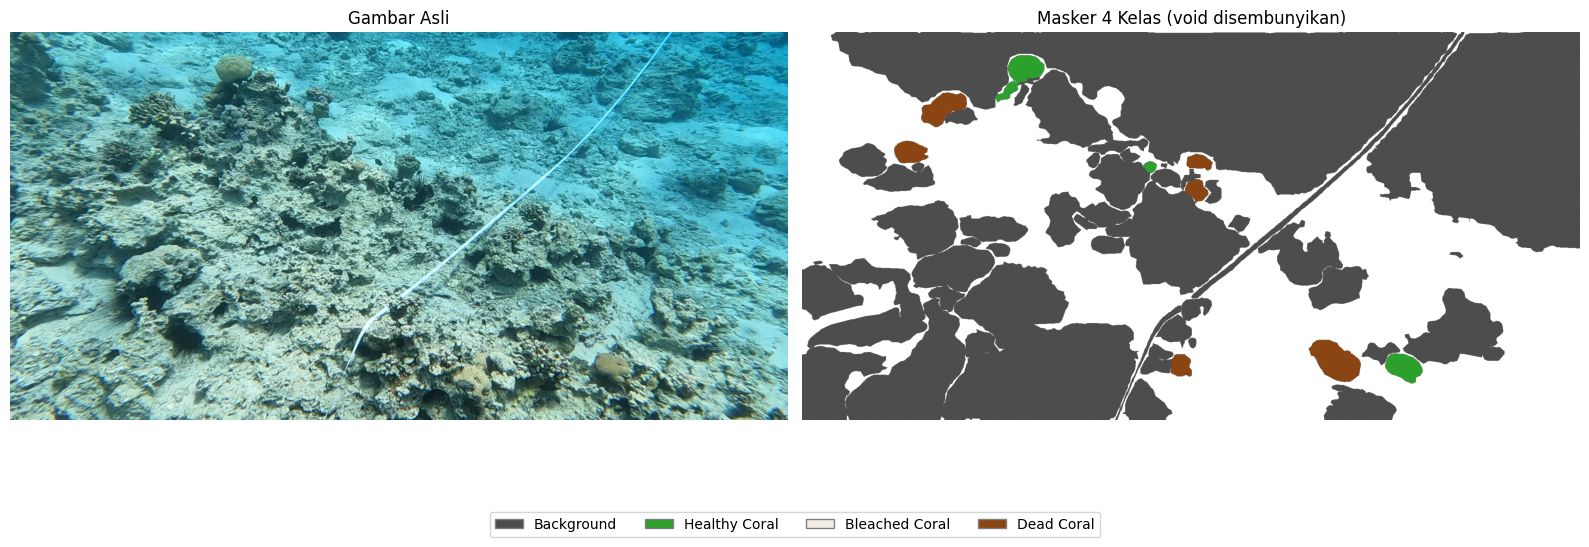

           Kelas  Jumlah Piksel  Persen (%)
      Background        1192914       56.88
(void/diabaikan)         863848       41.19
      Dead Coral          27537        1.31
   Healthy Coral          12853        0.61


In [7]:
sample = dataset["test"][42]
img = np.array(sample["image"].convert("RGB"))
mask4 = map_coral_classes(np.array(sample["label"]))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].imshow(img); ax[0].set_title("Gambar Asli"); ax[0].axis("off")
ax[1].imshow(np.ma.masked_equal(mask4, IGNORE_INDEX), cmap=CMAP, vmin=0, vmax=3)
ax[1].set_title("Masker 4 Kelas (void disembunyikan)"); ax[1].axis("off")
fig.legend(handles=LEGEND, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(); plt.show()

vals, cnts = np.unique(mask4, return_counts=True)
names = {0: "Background", 1: "Healthy Coral", 2: "Bleached Coral", 3: "Dead Coral", IGNORE_INDEX: "(void/diabaikan)"}
df = pd.DataFrame({"Kelas": [names.get(int(v), v) for v in vals],
                   "Jumlah Piksel": cnts,
                   "Persen (%)": (cnts / cnts.sum() * 100).round(2)}).sort_values("Jumlah Piksel", ascending=False)
print(df.to_string(index=False))

## Langkah 6 — Augmentasi, normalisasi, Dataset & DataLoader
`albumentations` menerapkan transformasi **geometris yang sama** ke gambar *dan* masker sekaligus (mencegah desinkronisasi — kelemahan tersembunyi pada versi awal). Augmentasi **warna** dibuat sangat ringan karena pemutihan pada dasarnya adalah perubahan warna; augmentasi warna berlebihan bisa membingungkan model. **Normalisasi ImageNet** wajib karena encoder memakai bobot pra-latih ImageNet.

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.RandomCrop(height=CROP_SIZE, width=CROP_SIZE),   # patch resolusi asli (tanpa distorsi rasio)
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.2),  # ringan
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(height=VAL_SIZE[0], width=VAL_SIZE[1]),   # jaga rasio 2:1
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class CoralDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.data = hf_split
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        image = np.array(item["image"].convert("RGB"))
        mask = map_coral_classes(np.array(item["label"]))   # petakan SEBELUM augmentasi
        aug = self.transform(image=image, mask=mask)
        return aug["image"], aug["mask"].long()

train_set = CoralDataset(dataset["train"], train_transform)
val_set   = CoralDataset(dataset["validation"], val_transform)

# num_workers=2 mempercepat loading; set 0 bila muncul error worker di Colab
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Batch training: {len(train_loader)} | Batch validasi: {len(val_loader)}")

Batch training: 759 | Batch validasi: 83


## Langkah 7 — Hitung bobot kelas otomatis
Kelas *bleached* dan *dead* sangat langka. Alih-alih menebak bobot manual, kita hitung dari **frekuensi piksel sebenarnya** memakai *median-frequency balancing*: kelas langka otomatis diberi bobot lebih besar. Estimasi dari subset acak agar cepat.

In [9]:
# Estimasi frekuensi piksel dari subset data latih (cepat, tanpa model)
n_sample = min(300, len(dataset["train"]))
idxs = np.random.choice(len(dataset["train"]), size=n_sample, replace=False)

counts = np.zeros(NUM_CLASSES, dtype=np.float64)
for i in idxs:
    m = map_coral_classes(np.array(dataset["train"][int(i)]["label"]))
    m = m[m != IGNORE_INDEX]
    counts += np.bincount(m.ravel(), minlength=NUM_CLASSES)[:NUM_CLASSES]

freq = counts / counts.sum()
median_freq = np.median(freq[freq > 0])
weights = np.clip(median_freq / freq, 0.5, 15.0)     # median-frequency balancing + batas aman
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)

print("Proporsi piksel per kelas:", dict(zip(CLASS_NAMES, (freq * 100).round(2))))
print("Bobot kelas             :", dict(zip(CLASS_NAMES, weights.round(2))))

Proporsi piksel per kelas: {'Background': np.float64(69.33), 'Healthy Coral': np.float64(26.46), 'Bleached Coral': np.float64(0.81), 'Dead Coral': np.float64(3.4)}
Bobot kelas             : {'Background': np.float64(0.5), 'Healthy Coral': np.float64(0.56), 'Bleached Coral': np.float64(15.0), 'Dead Coral': np.float64(4.39)}


## Langkah 8 — Bangun model U-Net
Encoder **ResNet-34** dengan bobot **ImageNet** (transfer learning). Output 4 kanal sesuai 4 kelas target.

In [10]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(device)

print("U-Net (encoder resnet34) siap di:", device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net (encoder resnet34) siap di: cuda


## Langkah 9 — Loss, optimizer, scaler
`CrossEntropyLoss` memakai **bobot kelas** + **`ignore_index`** (piksel void diabaikan). `AdamW` stabil untuk arsitektur berbasis ResNet. `GradScaler` mengaktifkan *mixed precision* (FP16) agar hemat memori & cepat di T4. Di sini dipakai API baru `torch.amp` (menggantikan `torch.cuda.amp` yang usang).

In [11]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda")
print("Loss, optimizer, dan scaler siap.")

Loss, optimizer, dan scaler siap.


## Langkah 10 — Fungsi training & validasi (dengan mIoU)
`validate()` menghitung *loss*, **IoU per kelas**, **mIoU**, dan **Coral mIoU** dalam satu lintasan memakai *confusion matrix*. Akurasi piksel juga mengabaikan void agar tidak menyesatkan.

In [12]:
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, masks in tqdm(loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        valid = masks != IGNORE_INDEX
        correct += (preds[valid] == masks[valid]).sum().item()
        total   += valid.sum().item()
    return running_loss / len(loader.dataset), 100.0 * correct / max(total, 1)

@torch.no_grad()
def validate(model, loader, criterion, device, num_classes=NUM_CLASSES):
    model.eval()
    running_loss = 0.0
    cm = np.zeros((num_classes, num_classes), dtype=np.float64)
    for images, masks in tqdm(loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)
        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, masks)
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        m = masks.cpu().numpy().ravel()
        p = preds.cpu().numpy().ravel()
        keep = m != IGNORE_INDEX
        if keep.any():
            cm += confusion_matrix(m[keep], p[keep], labels=list(range(num_classes)))
    iou = np.full(num_classes, np.nan)
    for i in range(num_classes):
        tp = cm[i, i]; fp = cm[:, i].sum() - tp; fn = cm[i, :].sum() - tp
        if (tp + fp + fn) > 0:
            iou[i] = tp / (tp + fp + fn)
    miou = np.nanmean(iou)
    coral_miou = np.nanmean(iou[1:])   # rata-rata kelas karang saja (1,2,3)
    return running_loss / len(loader.dataset), iou, miou, coral_miou

## Langkah 11 — Latih model + simpan checkpoint terbaik
Model terbaik dipilih berdasarkan **Coral mIoU** validasi (metrik paling relevan dengan tujuan), bukan sekadar loss. Ini juga berperan sebagai *early stopping* sederhana: bobot terbaik selalu tersimpan.

In [13]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "miou": [], "coral_miou": []}
best_coral_miou = -1.0

print("Mulai pelatihan U-Net...\n")
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss, iou, miou, coral_miou = validate(model, val_loader, criterion, device)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss);  history["miou"].append(miou)
    history["coral_miou"].append(coral_miou)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"  [Train] Loss: {tr_loss:.4f} | Pixel Acc: {tr_acc:.2f}%")
    print(f"  [Val]   Loss: {val_loss:.4f} | mIoU: {miou*100:.2f}% | Coral mIoU: {coral_miou*100:.2f}%")
    print(f"          IoU-> BG:{iou[0]*100:5.1f} Healthy:{iou[1]*100:5.1f} Bleached:{iou[2]*100:5.1f} Dead:{iou[3]*100:5.1f}")

    if coral_miou > best_coral_miou:
        best_coral_miou = coral_miou
        torch.save(model.state_dict(), CKPT_PATH)
        print("  [SAVED] Coral mIoU terbaik -> checkpoint disimpan.")
    print("-" * 60)

print(f"\nPelatihan selesai. Coral mIoU terbaik: {best_coral_miou*100:.2f}%")

Mulai pelatihan U-Net...



Training:   0%|          | 0/759 [00:00<?, ?it/s]

Validation:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch [1/15]
  [Train] Loss: 1.1203 | Pixel Acc: 61.54%
  [Val]   Loss: 1.0057 | mIoU: 27.64% | Coral mIoU: 11.60%
          IoU-> BG: 75.8 Healthy: 29.9 Bleached:  0.9 Dead:  4.0
  [SAVED] Coral mIoU terbaik -> checkpoint disimpan.
------------------------------------------------------------


Training:   0%|          | 0/759 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch [14/15]
  [Train] Loss: 0.8227 | Pixel Acc: 74.38%
  [Val]   Loss: 0.8980 | mIoU: 35.45% | Coral mIoU: 22.46%
          IoU-> BG: 74.4 Healthy: 35.7 Bleached: 15.3 Dead: 16.3
------------------------------------------------------------


Training:   0%|          | 0/759 [00:00<?, ?it/s]

Validation:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch [15/15]
  [Train] Loss: 0.8037 | Pixel Acc: 73.77%
  [Val]   Loss: 0.7631 | mIoU: 42.98% | Coral mIoU: 30.17%
          IoU-> BG: 81.4 Healthy: 41.8 Bleached: 27.1 Dead: 21.6
  [SAVED] Coral mIoU terbaik -> checkpoint disimpan.
------------------------------------------------------------

Pelatihan selesai. Coral mIoU terbaik: 30.17%


## Langkah 12 — Kurva pelatihan
Membandingkan *train* vs *val loss* (indikator overfitting) dan perkembangan mIoU antar-epoch.

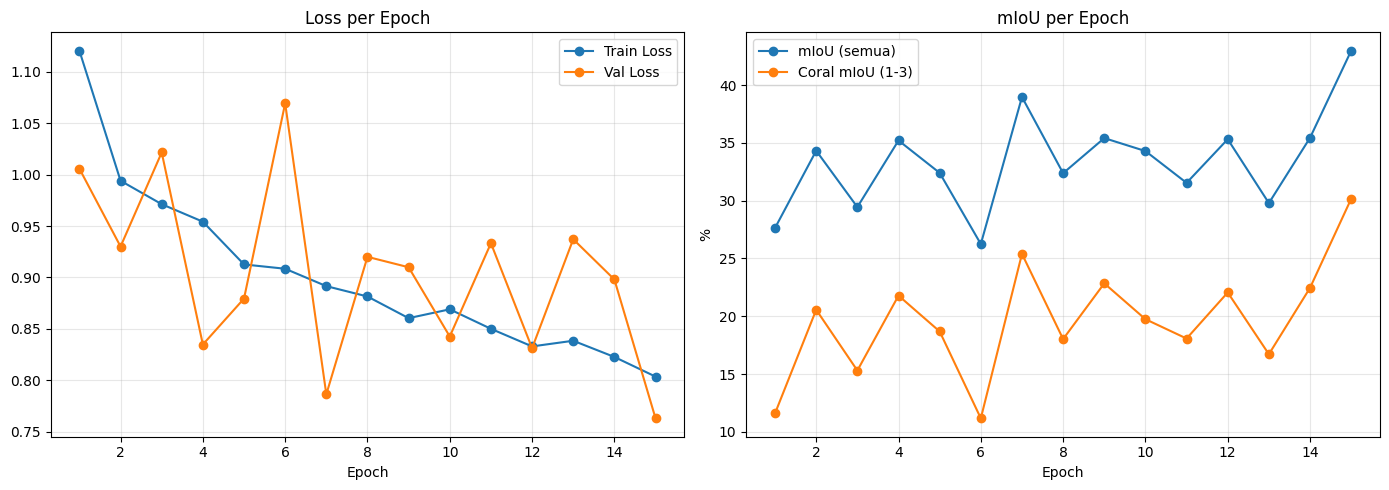

In [14]:
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(ep, history["train_loss"], marker="o", label="Train Loss")
ax[0].plot(ep, history["val_loss"],   marker="o", label="Val Loss")
ax[0].set_title("Loss per Epoch"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, np.array(history["miou"]) * 100,       marker="o", label="mIoU (semua)")
ax[1].plot(ep, np.array(history["coral_miou"]) * 100, marker="o", label="Coral mIoU (1-3)")
ax[1].set_title("mIoU per Epoch"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("%"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Langkah 13 — Evaluasi akhir (model terbaik)
Memuat checkpoint terbaik lalu menampilkan **rapor IoU per kelas**.

In [15]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
val_loss, iou, miou, coral_miou = validate(model, val_loader, criterion, device)

df = pd.DataFrame({"Kelas Bentik": CLASS_NAMES,
                   "IoU (%)": [f"{v*100:.2f}" if not np.isnan(v) else "N/A" for v in iou]})
print("=" * 48)
print(f"  mIoU (semua kelas): {miou*100:.2f}%   |   Coral mIoU: {coral_miou*100:.2f}%")
print("=" * 48)
print(df.to_string(index=False))

Validation:   0%|          | 0/83 [00:00<?, ?it/s]

  mIoU (semua kelas): 42.98%   |   Coral mIoU: 30.17%
  Kelas Bentik IoU (%)
    Background   81.43
 Healthy Coral   41.85
Bleached Coral   27.09
    Dead Coral   21.57


## Langkah 14 — Visualisasi prediksi & rasio pemutihan
Membandingkan gambar input, *ground truth* pakar, dan prediksi model. **Rasio bleaching** = piksel *bleached* ÷ (sehat + bleached). Karena IoU *bleached* masih terbatas, perlakukan angka ini sebagai estimasi, bukan pengukuran final.

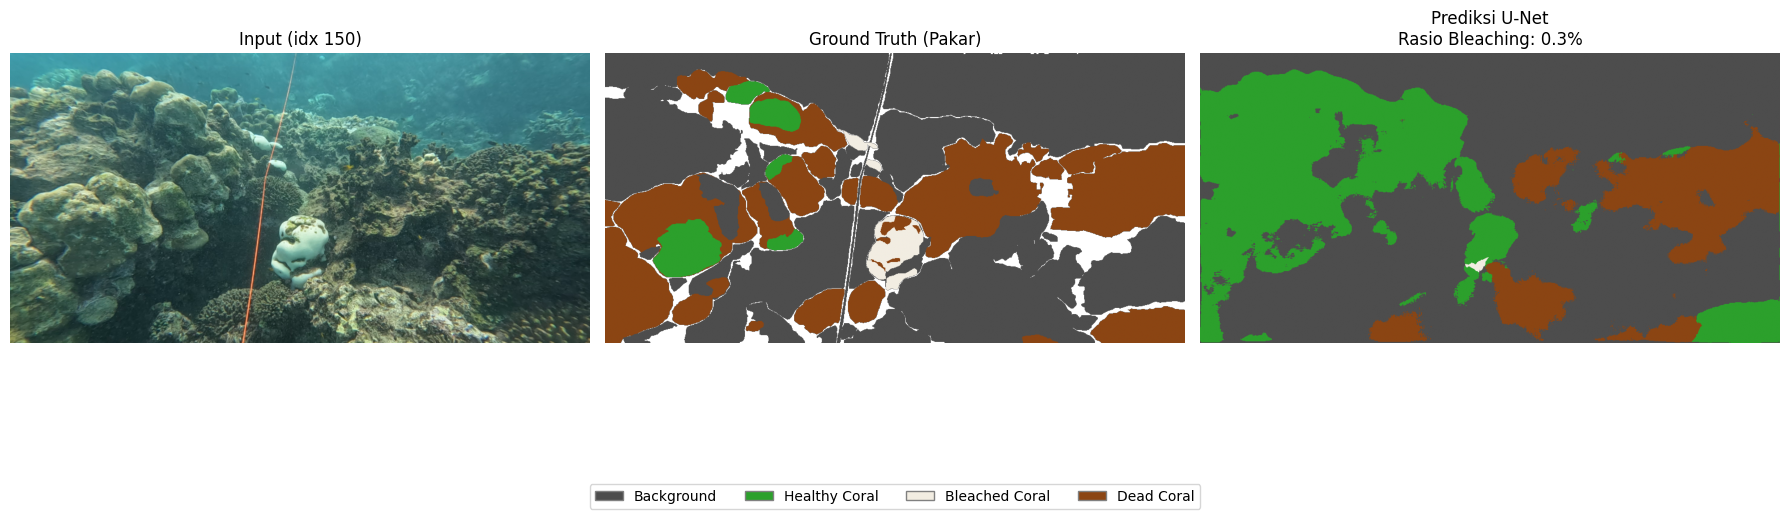

idx 150 -> Sehat: 134954 px | Bleached: 423 px | Mati: 66501 px | Rasio: 0.3%
------------------------------------------------------------------------------------------


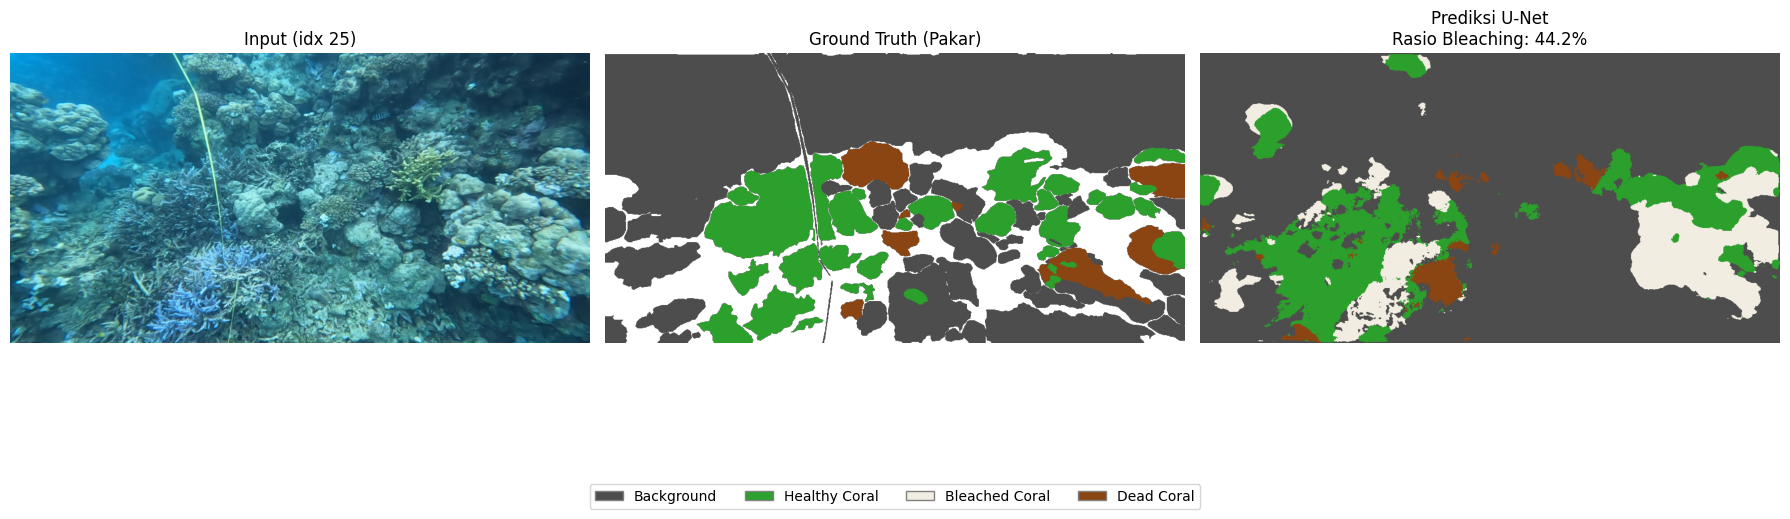

idx 25 -> Sehat: 73428 px | Bleached: 58086 px | Mati: 10769 px | Rasio: 44.2%
------------------------------------------------------------------------------------------


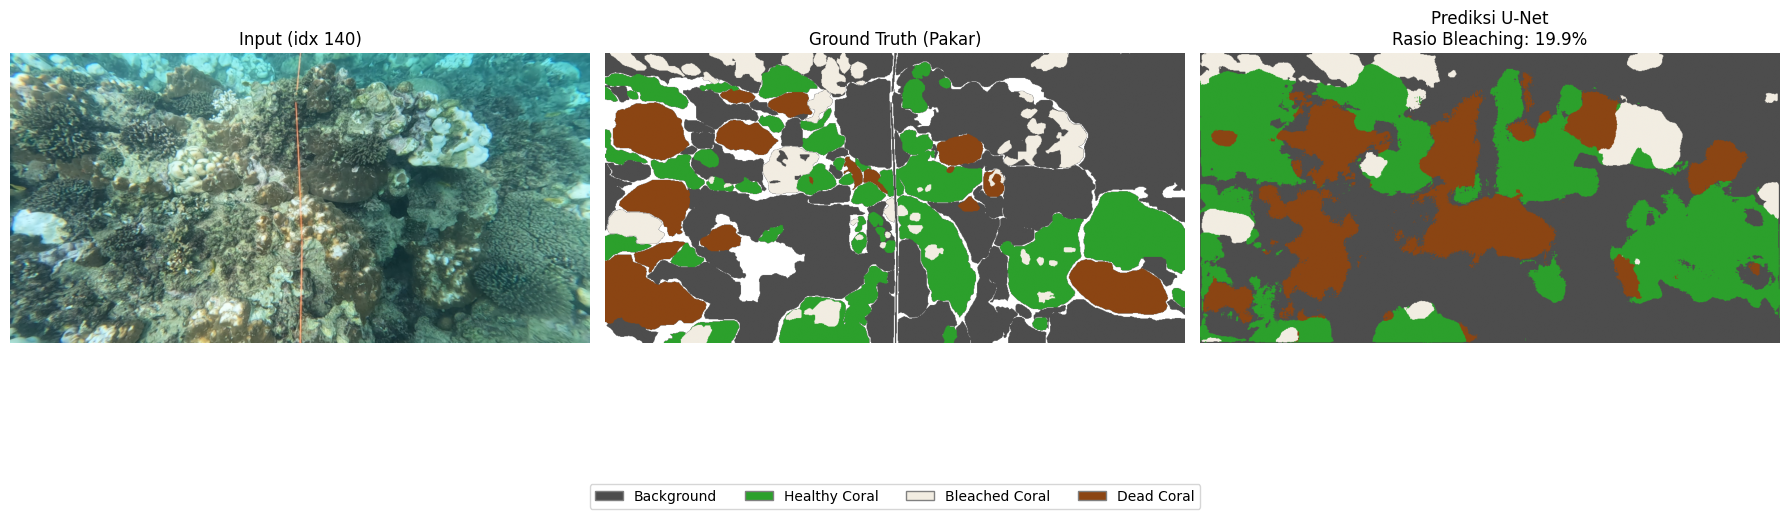

idx 140 -> Sehat: 144259 px | Bleached: 35887 px | Mati: 89118 px | Rasio: 19.9%
------------------------------------------------------------------------------------------


In [16]:
# denormalisasi untuk menampilkan gambar
INV_MEAN = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
INV_STD  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

@torch.no_grad()
def show_predictions(model, dataset_split, device, indices):
    model.eval()
    for idx in indices:
        image, mask_gt = dataset_split[idx]
        with torch.amp.autocast("cuda"):
            out = model(image.unsqueeze(0).to(device))
        pred = torch.argmax(out, dim=1).squeeze(0).cpu().numpy()
        mask_gt = mask_gt.numpy()

        healthy = int((pred == 1).sum()); bleached = int((pred == 2).sum()); dead = int((pred == 3).sum())
        live = healthy + bleached
        ratio = (bleached / live * 100) if live > 0 else 0.0

        img_show = (image.cpu() * INV_STD + INV_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()
        fig, ax = plt.subplots(1, 3, figsize=(18, 6))
        ax[0].imshow(img_show); ax[0].set_title(f"Input (idx {idx})"); ax[0].axis("off")
        ax[1].imshow(np.ma.masked_equal(mask_gt, IGNORE_INDEX), cmap=CMAP, vmin=0, vmax=3)
        ax[1].set_title("Ground Truth (Pakar)"); ax[1].axis("off")
        ax[2].imshow(pred, cmap=CMAP, vmin=0, vmax=3)
        ax[2].set_title(f"Prediksi U-Net\nRasio Bleaching: {ratio:.1f}%"); ax[2].axis("off")
        fig.legend(handles=LEGEND, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03))
        plt.tight_layout(); plt.show()
        print(f"idx {idx} -> Sehat: {healthy} px | Bleached: {bleached} px | Mati: {dead} px | Rasio: {ratio:.1f}%")
        print("-" * 90)

show_predictions(model, val_set, device, indices=[150, 25, 140])

## Langkah 15 — Simpan model (opsional ke Google Drive)
Checkpoint terbaik sudah tersimpan di `CKPT_PATH`. Sel di bawah menyimpan salinan final; buka komentar untuk menyalinnya ke Google Drive.

In [17]:
torch.save(model.state_dict(), "/content/unet_coral_final.pth")
print("Model final tersimpan: /content/unet_coral_final.pth")

# (Opsional) salin checkpoint terbaik ke Google Drive:
# from google.colab import drive
# drive.mount("/content/drive")
# !cp /content/best_unet_coral.pth /content/drive/MyDrive/best_unet_coral.pth
# print("Checkpoint disalin ke Google Drive.")

Model final tersimpan: /content/unet_coral_final.pth


## Catatan & saran lanjutan
- **Interpretasi metrik:** *Coral mIoU* lebih relevan daripada akurasi piksel. IoU *bleached/dead* yang rendah itu wajar karena kelas ini langka — di sinilah fokus perbaikan berikutnya.
- **Ide peningkatan:** gabungkan loss dengan **Dice** atau **Focal** (`smp.losses`), latih lebih lama, coba encoder lebih besar (mis. `resnet50` / `efficientnet-b3`), atau naikkan resolusi crop bila VRAM cukup.
- **Verifikasi label:** bila `Nilai maksimum label` di Langkah 4 tidak pernah mendekati 39 pada banyak sampel, periksa kembali konvensi indeks dataset sebelum menyimpulkan hasil.